# Generalization Experiment: Downstream Classification Evaluation

This notebook evaluates only the **generalization experiment**.

It compares the selected feature sets by their performance on the downstream **20-class MNIST + Fashion-MNIST classification task**.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

RESULT_PATH = '../results_generalization/raw_generalization_results.csv'

## 1. Load results

In [ ]:
df = pd.read_csv(RESULT_PATH)
classification_cols = [
    'experiment',
    'feature_source',
    'seed',
    'k',
    'accuracy',
]

df_cls = df[classification_cols].copy()
df_cls

,experiment,feature_source,seed,k,accuracy
0,generalization_mnist_fashion,unsupervised,0,50,0.817036
1,generalization_mnist_fashion,supervised,0,50,0.382714
2,generalization_mnist_fashion,unsupervised,1,50,0.812607
3,generalization_mnist_fashion,supervised,1,50,0.431357
4,generalization_mnist_fashion,unsupervised,2,50,0.815679
5,generalization_mnist_fashion,supervised,2,50,0.412571
6,generalization_mnist_fashion,unsupervised,3,50,0.811500
7,generalization_mnist_fashion,supervised,3,50,0.410643
8,generalization_mnist_fashion,unsupervised,4,50,0.813321
9,generalization_mnist_fashion,supervised,4,50,0.424071


## 2. Mean ± std over seeds

In [9]:
summary = (
    df_cls
    .groupby(['feature_source', 'k'])[[
        'accuracy',
    ]]
    .agg(['mean', 'std'])
)

summary

accuracy          
                       mean       std
feature_source k                     
supervised     50  0.412271  0.018573
unsupervised   50  0.814029  0.002274

## 3. Plot downstream classification accuracy

/var/folders/2d/rgh939n56knbdhv7tklttl740000gn/T/ipykernel_40272/3670290944.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/2d/rgh939n56knbdhv7tklttl740000gn/T/ipykernel_40272/3670290944.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


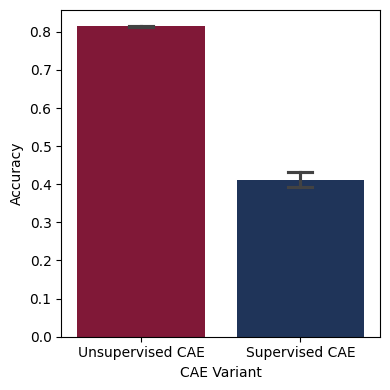

In [22]:
plot_df = (
    df_cls
    .groupby('feature_source')['accuracy']
    .agg(['mean', 'std'])
    .sort_values('mean', ascending=False)
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Order (optional if you want control)
order = plot_df.index.tolist()

# Color mapping (match previous plots)
palette = {
    "unsupervised": "#910730",
    "supervised": "#153163",
}

label_map = {
    "unsupervised": "Unsupervised CAE",
    "supervised": "Supervised CAE",
}

# Reset index for seaborn
plot_df_reset = plot_df.reset_index()

plt.figure(figsize=(4, 4))

ax = sns.barplot(
    data=df_cls,
    x="feature_source",
    y="accuracy",
    palette=palette,
    errorbar="sd",
    capsize=0.15
)


# Clean labels (optional nicer names)
ax.set_xticklabels(
    [label_map.get(x, x) for x in plot_df_reset["feature_source"]],
)

ax.set_ylabel("Accuracy")
ax.set_xlabel("CAE Variant")

plt.tight_layout()
plt.show()